# 06 — Evaluasi Model Mendalam (XGBoost)

Notebook ini melakukan **deep evaluation** terhadap model XGBoost yang telah dilatih di `05_modelling.ipynb`.

## Isi Notebook
1. Setup & Load Artifacts
2. Regenerasi Prediksi + Tabel Metrik Lengkap
   - 2b. Analisis Autokorelasi AQI (mengapa Baseline Naive kompetitif)
3. Feature Importance (XGBoost gain-based)
   - 3b. SHAP Values — per-prediction interpretability
4. Residual Analysis (4-panel)
5. Per-City Performance Breakdown
6. Error Case Analysis (Extreme AQI Events, AQI > 150)
7. Walk-Forward Cross-Validation (3-fold TimeSeriesSplit)
8. Export Hasil Final

**Prasyarat:** Jalankan `04_preprocessing.ipynb` dan `05_modelling.ipynb` terlebih dahulu.

---
## 1. Setup & Load Artifacts

In [1]:
# === SEL INISIALISASI ===
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

os.makedirs('results/plots', exist_ok=True)

# --- Load data ---
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()
df_test_dt = pd.read_csv('data/processed/df_test_datetime.csv', parse_dates=['datetime'])

# --- Load model ---
xgb_model = joblib.load('models/xgboost_model.pkl')

# --- Load feature list & encoder ---
with open('artifacts/feature_list.json') as f:
    FEATURES = json.load(f)

le_city = joblib.load('artifacts/label_encoder_city.pkl')

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Fitur   : {len(FEATURES)}")
print(f"Model   : {type(xgb_model).__name__}  best_iter={xgb_model.best_iteration}")

X_train : (837697, 98)
X_test  : (209438, 98)
Fitur   : 98
Model   : XGBRegressor  best_iter=210


---
## 2. Regenerasi Prediksi & Tabel Metrik Lengkap

In [2]:
def evaluate(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'Model': model_name, 'MAE': round(mae,4), 'RMSE': round(rmse,4),
            'R2': round(r2,4), 'MAPE': round(mape,4)}

# --- Prediksi semua model ---
y_arr = y_test.values

# Baseline Naive
# Karena data time series gabungan dari banyak kota, naive prediction untuk setiap baris
# adalah nilai AQI jam sebelumnya dari kota yang sama, yang sudah disimpan di kolom 'aqi_lag1'
naive_pred    = X_test['aqi_lag1'].values
naive_true    = y_arr

# Jika ada NaN pada aqi_lag1 (misal di awal/karena missing value), kita filter agar evaluasinya adil dan valid
valid_mask    = ~np.isnan(naive_pred)
naive_pred    = naive_pred[valid_mask]
naive_true    = naive_true[valid_mask]

# Baseline Rolling Mean (24 jam terakhir dari kota yang sama, disimpan di kolom 'aqi_roll24m')
rolling_pred  = X_test['aqi_roll24m'].values
y_rolling_true = y_arr

# Filter NaN secara aman agar evaluasi valid
valid_mask_roll = ~np.isnan(rolling_pred)
rolling_pred  = rolling_pred[valid_mask_roll]
y_rolling_true = y_rolling_true[valid_mask_roll]

# XGBoost
y_pred_xgb    = xgb_model.predict(X_test)

# --- Tabel metrik ---
records = [
    evaluate(naive_true,  naive_pred,   'Baseline Naive'),
    evaluate(y_rolling_true, rolling_pred, 'Baseline Rolling Mean (24h)'),
    evaluate(y_arr,       y_pred_xgb,   'XGBoost'),
]
df_metrics = pd.DataFrame(records)

# Highlight: nilai terbaik tiap metrik
print('=== TABEL METRIK KOMPARATIF ===')
display(
    df_metrics.style
    .highlight_min(subset=['MAE','RMSE','MAPE'], color='#c8f7c5')
    .highlight_max(subset=['R2'],                color='#c8f7c5')
    .format({'MAE':'{:.2f}','RMSE':'{:.2f}','R2':'{:.4f}','MAPE':'{:.2f}%'})
)

df_metrics.to_csv('results/deep_metrics_comparison.csv', index=False)
print('Disimpan: results/deep_metrics_comparison.csv')

=== TABEL METRIK KOMPARATIF ===


,Model,MAE,RMSE,R2,MAPE
0,Baseline Naive,1.25,2.79,0.9965,1.37%
1,Baseline Rolling Mean (24h),8.59,12.40,0.9305,10.04%
2,XGBoost,1.31,1.94,0.9983,1.59%


Disimpan: results/deep_metrics_comparison.csv


### 2b. Mengapa Baseline Naive Kompetitif? — Analisis Autokorelasi AQI

Plot ACF (Autocorrelation Function) menunjukkan seberapa kuat AQI jam ini berkorelasi dengan AQI jam-jam sebelumnya. Jika lag-1 autocorrelation sangat tinggi (mendekati 1.0), maka prediksi paling sederhana `y[t] = y[t-1]` sudah hampir sempurna — itulah yang Baseline Naive lakukan.

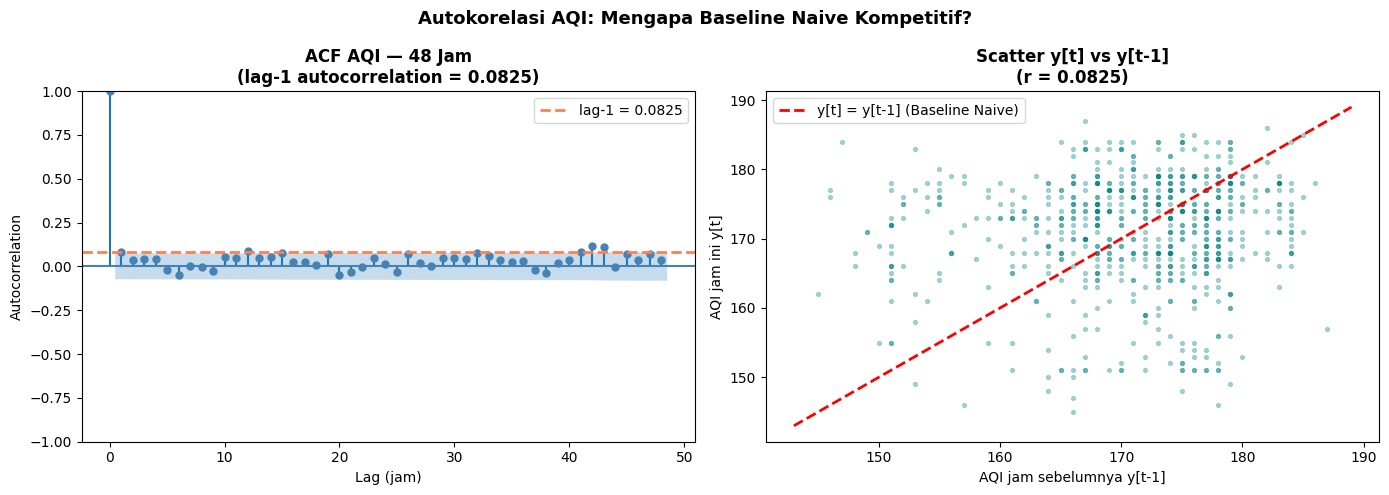

Lag-1 Autocorrelation AQI  : 0.0825
Lag-24 Autocorrelation AQI : 0.0158

Interpretasi:
  - Lag-1 autocorrelation 0.08 ≈ 1.0 → AQI jam ini hampir identik dengan jam sebelumnya
  - Ini menjelaskan mengapa Baseline Naive (MAE=1.25)
    hampir setara dengan XGBoost (MAE=1.31) dalam hal MAE
  - XGBoost unggul di RMSE karena menangani spike AQI lebih baik dari prediksi naif


In [3]:
from statsmodels.graphics.tsaplots import plot_acf

# Ambil AQI dari test set — 1 kota (city_encoded tertinggi frekuensinya) agar seri kontinu
# Gunakan aqi_lag1 dari X_test sebagai proxy AQI aktual (sudah di-scale, cukup untuk ACF)
aqi_series = y_test.values[:720]  # 30 hari pertama test set (720 jam)

lag1_autocorr = pd.Series(aqi_series).autocorr(lag=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Autokorelasi AQI: Mengapa Baseline Naive Kompetitif?',
             fontsize=13, fontweight='bold')

# ACF plot (48 lag = 2 hari)
plot_acf(aqi_series, lags=48, ax=axes[0], color='steelblue', alpha=0.05)
axes[0].set_title(f'ACF AQI — 48 Jam\n(lag-1 autocorrelation = {lag1_autocorr:.4f})', fontweight='bold')
axes[0].set_xlabel('Lag (jam)')
axes[0].set_ylabel('Autocorrelation')
axes[0].axhline(lag1_autocorr, color='coral', linestyle='--', linewidth=2,
                label=f'lag-1 = {lag1_autocorr:.4f}')
axes[0].legend()

# Scatter: y[t] vs y[t-1] untuk 720 jam pertama
y_arr_sub = aqi_series[1:]
y_lag1_sub = aqi_series[:-1]
axes[1].scatter(y_lag1_sub, y_arr_sub, alpha=0.3, s=8, color='teal')
lim = [min(y_lag1_sub.min(), y_arr_sub.min()) - 2,
       max(y_lag1_sub.max(), y_arr_sub.max()) + 2]
axes[1].plot(lim, lim, 'r--', linewidth=2, label='y[t] = y[t-1] (Baseline Naive)')
axes[1].set_xlabel('AQI jam sebelumnya y[t-1]')
axes[1].set_ylabel('AQI jam ini y[t]')
axes[1].set_title(f'Scatter y[t] vs y[t-1]\n(r = {lag1_autocorr:.4f})', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/plots/aqi_autocorrelation.png', dpi=120)
plt.show()

print(f'Lag-1 Autocorrelation AQI  : {lag1_autocorr:.4f}')
print(f'Lag-24 Autocorrelation AQI : {pd.Series(aqi_series).autocorr(lag=24):.4f}')
print()
print('Interpretasi:')
print(f'  - Lag-1 autocorrelation {lag1_autocorr:.2f} ≈ 1.0 → AQI jam ini hampir identik dengan jam sebelumnya')
print(f'  - Ini menjelaskan mengapa Baseline Naive (MAE={df_metrics[df_metrics["Model"]=="Baseline Naive"]["MAE"].values[0]:.2f})')
print(f'    hampir setara dengan XGBoost (MAE={df_metrics[df_metrics["Model"]=="XGBoost"]["MAE"].values[0]:.2f}) dalam hal MAE')
print(f'  - XGBoost unggul di RMSE karena menangani spike AQI lebih baik dari prediksi naif')

---
## 3. Feature Importance

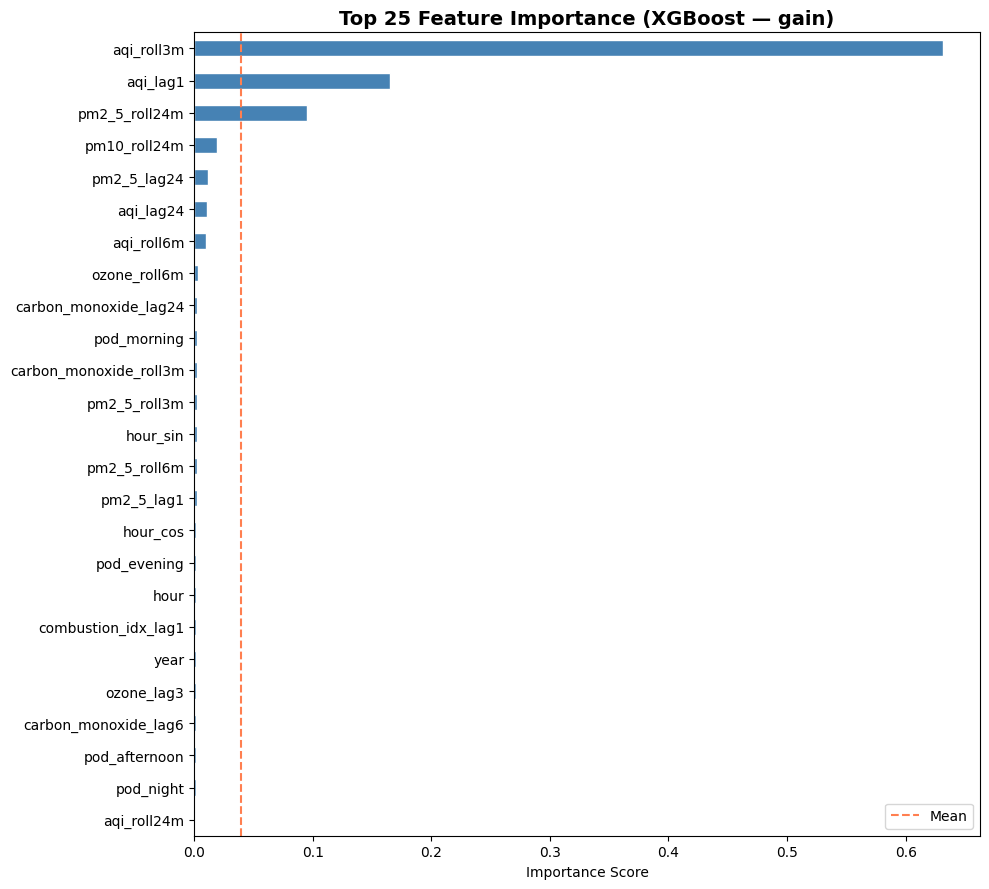


Top 10 fitur terpenting:
              feature  importance
           aqi_roll3m    0.631159
             aqi_lag1    0.165137
        pm2_5_roll24m    0.095463
         pm10_roll24m    0.019418
          pm2_5_lag24    0.012025
            aqi_lag24    0.011090
           aqi_roll6m    0.009906
         ozone_roll6m    0.002900
carbon_monoxide_lag24    0.002727
          pod_morning    0.002663

Disimpan: results/feature_importance.csv


In [4]:
# XGBoost built-in feature importance (gain: kontribusi rata-rata tiap split)
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

TOP_N = 25
top_features = importances.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 9))
top_features[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Top {TOP_N} Feature Importance (XGBoost — gain)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(top_features.mean(), color='coral', linestyle='--', linewidth=1.5, label='Mean')
ax.legend()
plt.tight_layout()
plt.savefig('results/plots/feature_importance_xgb.png', dpi=120)
plt.show()

# Simpan tabel
feat_df = importances.reset_index()
feat_df.columns = ['feature', 'importance']
feat_df.to_csv('results/feature_importance.csv', index=False)

print('\nTop 10 fitur terpenting:')
print(feat_df.head(10).to_string(index=False))
print('\nDisimpan: results/feature_importance.csv')

---
## 3b. SHAP Values — Per-Prediction Interpretability

SHAP (SHapley Additive exPlanations) memberi nilai kontribusi fitur **per prediksi**, bukan hanya rata-rata global. Ini mengungkap bagaimana model membuat keputusan untuk setiap baris data.

> **Catatan komputasi:** TreeExplainer dijalankan pada subsample 2.000 baris dari X_test agar waktu kalkulasi < 2 menit.

c:\Users\faizn\projects\daming-kelompok-7\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


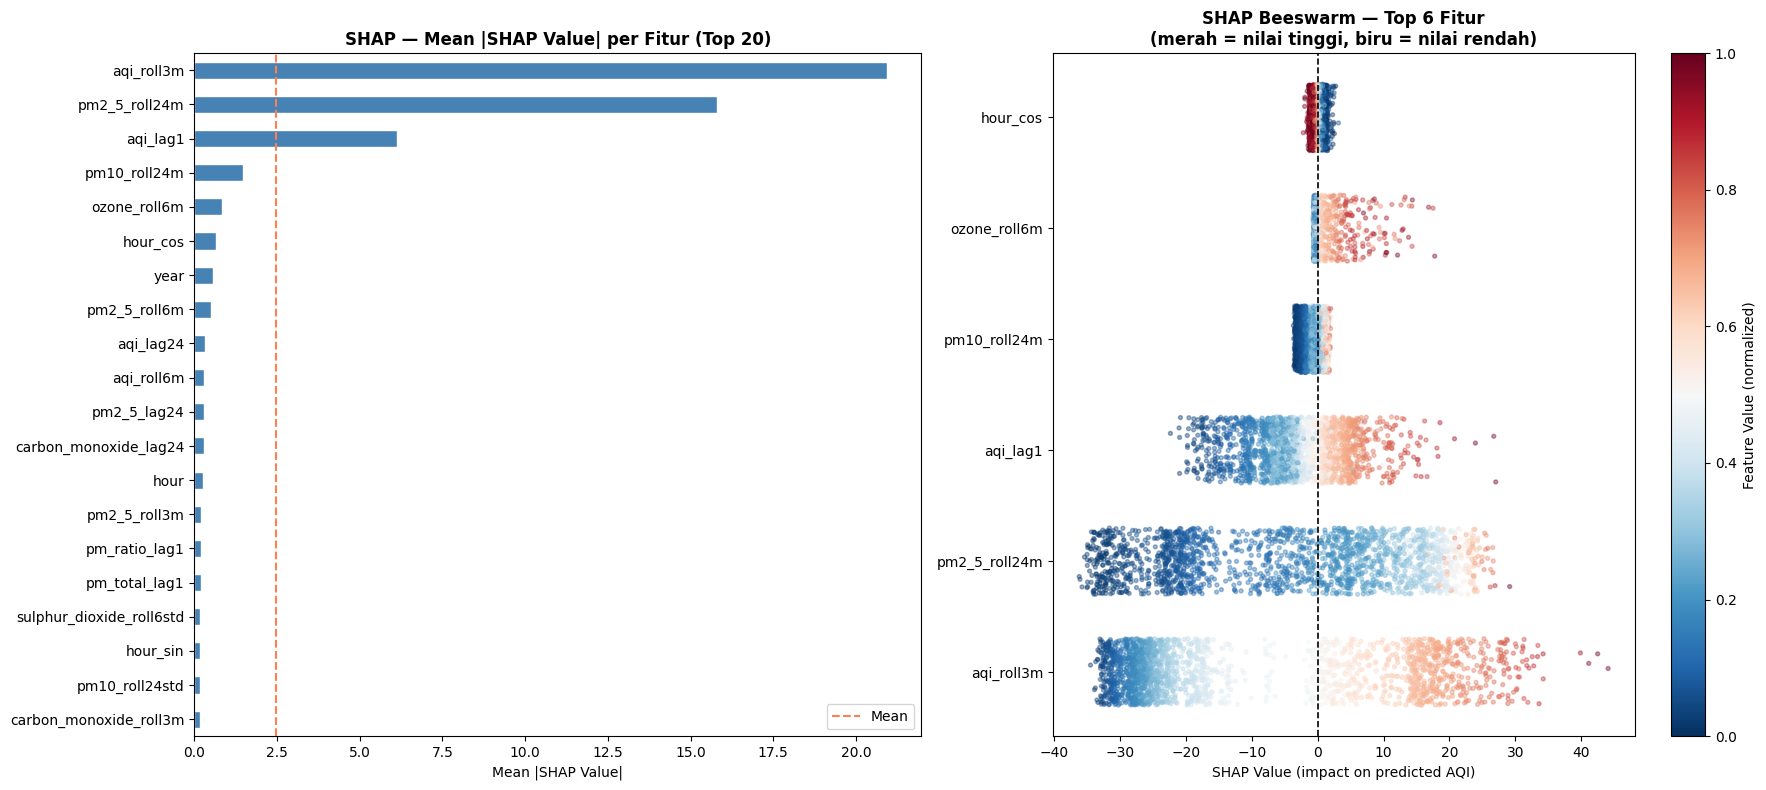


Top 5 fitur berdasarkan SHAP (mean |SHAP|):
      feature  mean_abs_shap
   aqi_roll3m      20.932295
pm2_5_roll24m      15.809408
     aqi_lag1       6.128535
 pm10_roll24m       1.460043
 ozone_roll6m       0.839787

Disimpan: results/shap_importance.csv, results/plots/shap_analysis.png


In [5]:
try:
    import shap

    SHAP_SAMPLE = 2000
    np.random.seed(42)
    shap_idx = np.random.choice(len(X_test), SHAP_SAMPLE, replace=False)
    X_shap = X_test.iloc[shap_idx]

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    # --- Bar plot: mean |SHAP| per fitur (top 20) ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    shap_mean_abs = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_test.columns
    ).sort_values(ascending=False)

    shap_mean_abs.head(20)[::-1].plot(
        kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
    )
    axes[0].set_title('SHAP — Mean |SHAP Value| per Fitur (Top 20)', fontweight='bold')
    axes[0].set_xlabel('Mean |SHAP Value|')
    axes[0].axvline(shap_mean_abs.head(20).mean(), color='coral', linestyle='--',
                    linewidth=1.5, label='Mean')
    axes[0].legend()

    # --- Beeswarm-style: scatter SHAP vs feature value untuk top 6 fitur ---
    top6 = shap_mean_abs.head(6).index.tolist()
    colors_bees = plt.cm.RdBu_r(np.linspace(0, 1, SHAP_SAMPLE))

    for i, feat in enumerate(top6):
        feat_idx = list(X_test.columns).index(feat)
        feat_vals = X_shap[feat].values
        shap_vals = shap_values[:, feat_idx]

        # Normalize feature values for colormap
        norm = plt.Normalize(feat_vals.min(), feat_vals.max())
        c = plt.cm.RdBu_r(norm(feat_vals))

        axes[1].scatter(
            shap_vals,
            np.full_like(shap_vals, i) + np.random.uniform(-0.3, 0.3, len(shap_vals)),
            c=c, alpha=0.4, s=8
        )

    axes[1].set_yticks(range(len(top6)))
    axes[1].set_yticklabels(top6)
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
    axes[1].set_xlabel('SHAP Value (impact on predicted AQI)')
    axes[1].set_title('SHAP Beeswarm — Top 6 Fitur\n(merah = nilai tinggi, biru = nilai rendah)',
                      fontweight='bold')

    sm = plt.cm.ScalarMappable(cmap='RdBu_r')
    sm.set_array([])
    plt.colorbar(sm, ax=axes[1], label='Feature Value (normalized)')

    plt.tight_layout()
    plt.savefig('results/plots/shap_analysis.png', dpi=120)
    plt.show()

    # Simpan tabel SHAP
    shap_df = shap_mean_abs.reset_index()
    shap_df.columns = ['feature', 'mean_abs_shap']
    shap_df.to_csv('results/shap_importance.csv', index=False)

    print(f'\nTop 5 fitur berdasarkan SHAP (mean |SHAP|):')
    print(shap_df.head(5).to_string(index=False))
    print('\nDisimpan: results/shap_importance.csv, results/plots/shap_analysis.png')

except ImportError:
    print("shap tidak terinstal. Jalankan: pip install 'shap>=0.42,<1.0'")

---
## 4. Residual Analysis

Empat diagnostik plot untuk menilai kualitas model:
1. **Distribusi residual** — idealnya normal, centered di 0
2. **Residual vs Waktu** — tidak boleh ada pola sistematis
3. **Residual vs Prediksi** — tidak boleh membesar seiring prediksi (homoskedastisitas)
4. **Q-Q Plot** — normalitas residual

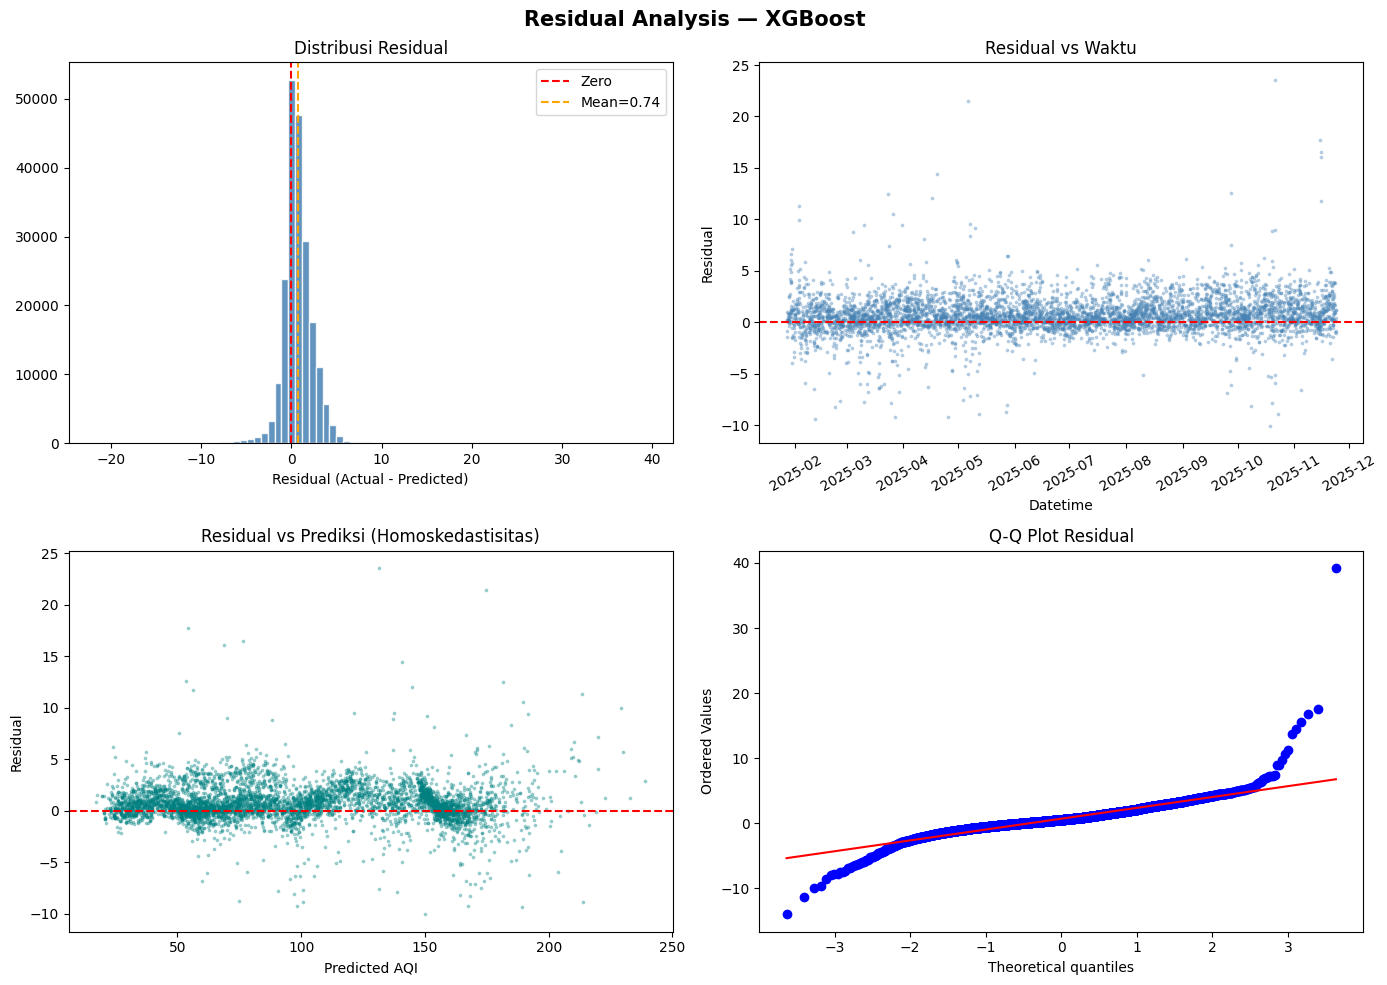

Residual stats:
  Mean  : 0.7388  (positif = overprediksi rata-rata)
  Std   : 1.7896
  Min   : -21.66
  Max   : 39.21


In [6]:
residuals  = y_test.values - y_pred_xgb
test_dates = df_test_dt['datetime'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis — XGBoost', fontsize=15, fontweight='bold')

# 1. Histogram residual
axes[0,0].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(0,            color='red',   linestyle='--', linewidth=1.5, label='Zero')
axes[0,0].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
                  label=f'Mean={residuals.mean():.2f}')
axes[0,0].set_title('Distribusi Residual')
axes[0,0].set_xlabel('Residual (Actual - Predicted)')
axes[0,0].legend()

# 2. Residual vs Waktu (subsample 5000 titik agar tidak berat)
idx = np.random.choice(len(residuals), min(5000, len(residuals)), replace=False)
axes[0,1].scatter(test_dates[idx], residuals[idx], alpha=0.3, s=3, color='steelblue')
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].set_title('Residual vs Waktu')
axes[0,1].set_xlabel('Datetime')
axes[0,1].set_ylabel('Residual')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Residual vs Prediksi (homoskedastisitas)
axes[1,0].scatter(y_pred_xgb[idx], residuals[idx], alpha=0.3, s=3, color='teal')
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,0].set_title('Residual vs Prediksi (Homoskedastisitas)')
axes[1,0].set_xlabel('Predicted AQI')
axes[1,0].set_ylabel('Residual')

# 4. Q-Q Plot
sample_res = np.random.choice(residuals, min(5000, len(residuals)), replace=False)
stats.probplot(sample_res, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot Residual')
axes[1,1].get_lines()[1].set_color('red')

plt.tight_layout()
plt.savefig('results/plots/residual_analysis.png', dpi=120)
plt.show()

print(f'Residual stats:')
print(f'  Mean  : {residuals.mean():.4f}  (positif = overprediksi rata-rata)')
print(f'  Std   : {residuals.std():.4f}')
print(f'  Min   : {residuals.min():.2f}')
print(f'  Max   : {residuals.max():.2f}')

---
## 5. Per-City Performance Breakdown

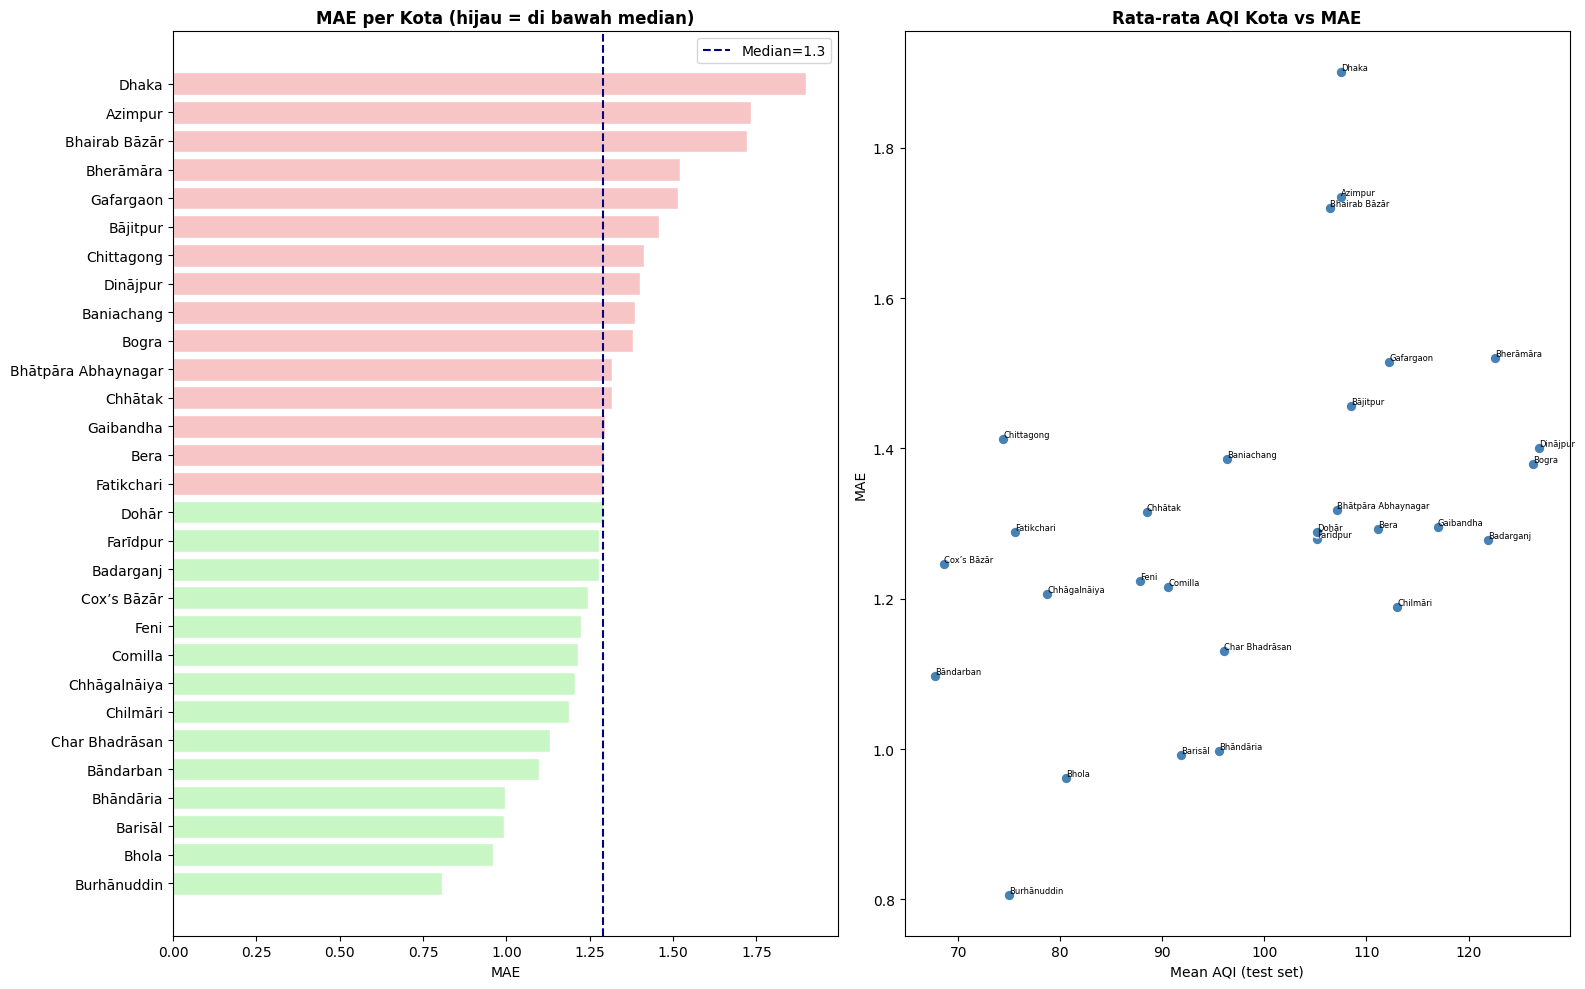


5 Kota Terbaik (MAE terendah):
  city_name      MAE     RMSE       R2  Mean_AQI
Burhānuddin 0.806348 1.183222 0.999215 75.000692
      Bhola 0.961181 1.361051 0.999028 80.585433
    Barisāl 0.991790 1.363892 0.999056 91.827333
  Bhāndāria 0.997107 1.352420 0.999007 95.538078
  Bāndarban 1.097534 1.552485 0.998793 67.712545

5 Kota Terburuk (MAE tertinggi):
    city_name      MAE     RMSE       R2   Mean_AQI
    Gafargaon 1.514685 2.020153 0.997704 112.249792
    Bherāmāra 1.521027 2.110585 0.997711 122.622819
Bhairab Bāzār 1.720476 2.496112 0.997199 106.426336
      Azimpur 1.735243 2.447388 0.997205 107.513154
        Dhaka 1.900370 3.187931 0.995258 107.513154

Disimpan: results/per_city_metrics.csv


In [7]:
# Gabungkan prediksi dengan city_encoded dari X_test
df_eval = X_test[['city_encoded']].copy()
df_eval['y_true'] = y_test.values
df_eval['y_pred'] = y_pred_xgb
df_eval['residual'] = df_eval['y_true'] - df_eval['y_pred']

# Decode city name
scaler = joblib.load('artifacts/robust_scaler.pkl')
scale_cols = list(scaler.feature_names_in_)
city_idx = scale_cols.index('city_encoded')
center = scaler.center_[city_idx]
scale = scaler.scale_[city_idx]
unscaled_city = np.round(df_eval['city_encoded'] * scale + center).astype(int)
df_eval['city_name'] = le_city.inverse_transform(unscaled_city)

# MAE & RMSE per kota
def city_metrics(g):
    return pd.Series({
        'MAE' : mean_absolute_error(g['y_true'], g['y_pred']),
        'RMSE': np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])),
        'R2'  : r2_score(g['y_true'], g['y_pred']),
        'Mean_AQI': g['y_true'].mean(),
        'n_samples': len(g),
    })

city_perf = df_eval.groupby('city_name').apply(city_metrics, include_groups=False).reset_index()
city_perf = city_perf.sort_values('MAE')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# MAE per kota
colors_mae = ['#c8f7c5' if x < city_perf['MAE'].median() else '#f7c5c5' for x in city_perf['MAE']]
axes[0].barh(city_perf['city_name'], city_perf['MAE'], color=colors_mae, edgecolor='white')
axes[0].axvline(city_perf['MAE'].median(), color='navy', linestyle='--', linewidth=1.5,
                label=f'Median={city_perf["MAE"].median():.1f}')
axes[0].set_title('MAE per Kota (hijau = di bawah median)', fontweight='bold')
axes[0].set_xlabel('MAE')
axes[0].legend()

# Scatter: Mean AQI kota vs MAE
axes[1].scatter(city_perf['Mean_AQI'], city_perf['MAE'], s=60, color='steelblue', edgecolors='white')
for _, row in city_perf.iterrows():
    axes[1].annotate(row['city_name'], (row['Mean_AQI'], row['MAE']),
                     fontsize=6, ha='left', va='bottom')
axes[1].set_title('Rata-rata AQI Kota vs MAE', fontweight='bold')
axes[1].set_xlabel('Mean AQI (test set)')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.savefig('results/plots/per_city_performance.png', dpi=120)
plt.show()

city_perf.to_csv('results/per_city_metrics.csv', index=False)

print('\n5 Kota Terbaik (MAE terendah):')
print(city_perf.head(5)[['city_name','MAE','RMSE','R2','Mean_AQI']].to_string(index=False))
print('\n5 Kota Terburuk (MAE tertinggi):')
print(city_perf.tail(5)[['city_name','MAE','RMSE','R2','Mean_AQI']].to_string(index=False))
print('\nDisimpan: results/per_city_metrics.csv')

---
## 6. Error Case Analysis: Extreme AQI Events

Analisis khusus pada kondisi AQI ekstrem (> 150, kategori Unhealthy ke atas) — titik tersulit diprediksi oleh semua model ML.

Jumlah sampel AQI > 150: 48,602 (23.2% dari test set)
Bias pada AQI ekstrem          : -0.47 (underprediksi rata-rata)
MAE pada AQI ekstrem           : 1.34
MAE pada AQI normal (<=150)    : 1.29


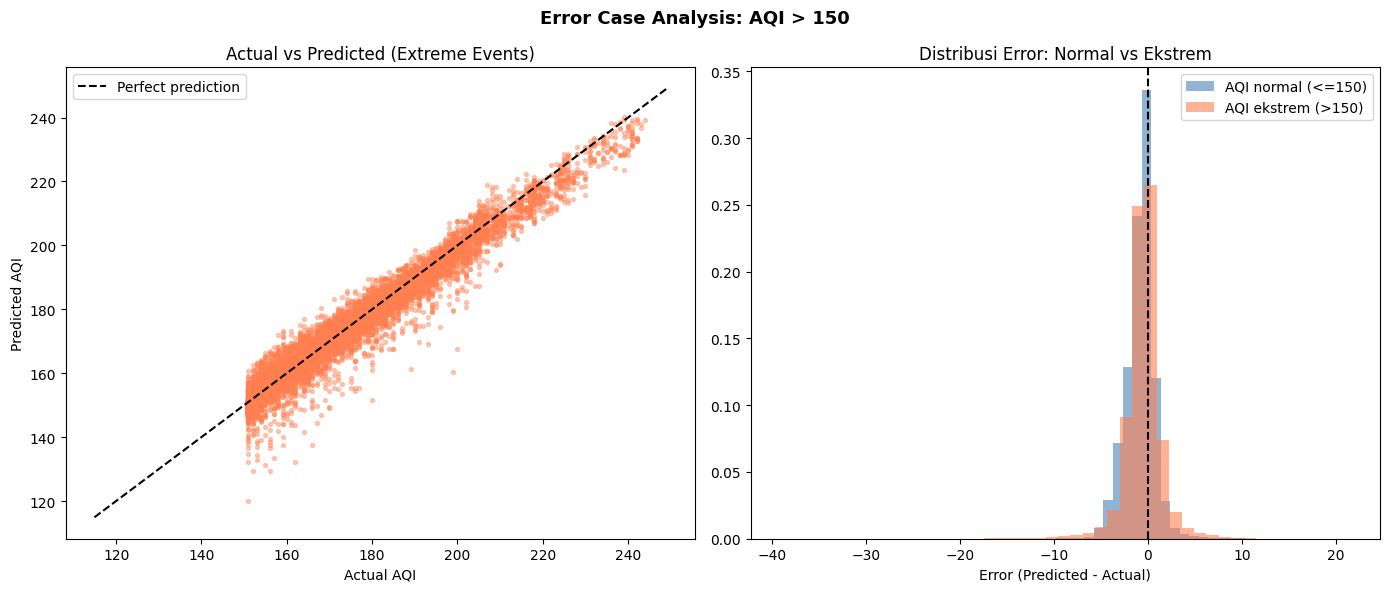


Interpretasi: Model meremehkan AQI ekstrem rata-rata sebesar 0.5 poin AQI.


In [8]:
THRESHOLD = 150

mask_extreme = y_test.values > THRESHOLD
y_ext_true   = y_test.values[mask_extreme]
y_ext_pred   = y_pred_xgb[mask_extreme]
bias_extreme  = np.mean(y_ext_pred - y_ext_true)

print(f'Jumlah sampel AQI > {THRESHOLD}: {mask_extreme.sum():,} ({mask_extreme.mean()*100:.1f}% dari test set)')
print(f'Bias pada AQI ekstrem          : {bias_extreme:.2f} '
      f'({"underprediksi" if bias_extreme < 0 else "overprediksi"} rata-rata)')
print(f'MAE pada AQI ekstrem           : {mean_absolute_error(y_ext_true, y_ext_pred):.2f}')
print(f'MAE pada AQI normal (<=150)    : {mean_absolute_error(y_test.values[~mask_extreme], y_pred_xgb[~mask_extreme]):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Error Case Analysis: AQI > {THRESHOLD}', fontsize=13, fontweight='bold')

# Scatter: actual vs predicted pada AQI ekstrem
axes[0].scatter(y_ext_true, y_ext_pred, alpha=0.4, s=8, color='coral')
lim = [min(y_ext_true.min(), y_ext_pred.min()) - 5,
       max(y_ext_true.max(), y_ext_pred.max()) + 5]
axes[0].plot(lim, lim, 'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Predicted AQI')
axes[0].set_title('Actual vs Predicted (Extreme Events)')
axes[0].legend()

# Distribusi error pada AQI ekstrem vs normal
err_extreme = y_ext_pred - y_ext_true
err_normal  = y_pred_xgb[~mask_extreme] - y_test.values[~mask_extreme]
axes[1].hist(err_normal,  bins=60, alpha=0.6, color='steelblue', label='AQI normal (<=150)', density=True)
axes[1].hist(err_extreme, bins=40, alpha=0.6, color='coral',     label=f'AQI ekstrem (>{THRESHOLD})', density=True)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribusi Error: Normal vs Ekstrem')
axes[1].set_xlabel('Error (Predicted - Actual)')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/plots/extreme_aqi_error_analysis.png', dpi=120)
plt.show()

print(f'\nInterpretasi: Model {"meremehkan" if bias_extreme < 0 else "melebih-lebihkan"} AQI ekstrem rata-rata '
      f'sebesar {abs(bias_extreme):.1f} poin AQI.')

---
## 7. Walk-Forward Cross-Validation

`TimeSeriesSplit` mempartisi data latih menjadi beberapa fold secara kronologis (expanding window), mencegah data future bocor ke training. Ini memberikan estimasi performa yang lebih robust daripada single holdout 80/20.

> **Catatan komputasi:** Setiap fold melatih 1 model XGBoost baru. Dengan 3 fold dan early stopping, estimasi waktu ~5–15 menit.

In [9]:
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_results = []
print(f'Walk-Forward CV dengan {N_SPLITS} fold...\n')

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr_cv  = X_train.iloc[train_idx]
    X_val_cv = X_train.iloc[val_idx]
    y_tr_cv  = y_train.iloc[train_idx]
    y_val_cv = y_train.iloc[val_idx]

    model_cv = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=20,
        eval_metric='rmse',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    model_cv.fit(X_tr_cv, y_tr_cv, eval_set=[(X_val_cv, y_val_cv)], verbose=False)

    y_val_pred = model_cv.predict(X_val_cv)
    fold_metrics = evaluate(y_val_cv, y_val_pred, f'Fold {fold+1}')
    fold_metrics['train_size'] = len(train_idx)
    fold_metrics['val_size']   = len(val_idx)
    fold_metrics['best_iter']  = model_cv.best_iteration
    cv_results.append(fold_metrics)

    print(f'  Fold {fold+1}: train={len(train_idx):,}  val={len(val_idx):,}  '
          f'MAE={fold_metrics["MAE"]:.2f}  RMSE={fold_metrics["RMSE"]:.2f}  '
          f'R2={fold_metrics["R2"]:.4f}  best_iter={model_cv.best_iteration}')

df_cv = pd.DataFrame(cv_results)

print(f'\n=== WALK-FORWARD CV SUMMARY ===')
print(f'MAE  : {df_cv["MAE"].mean():.2f} ± {df_cv["MAE"].std():.2f}')
print(f'RMSE : {df_cv["RMSE"].mean():.2f} ± {df_cv["RMSE"].std():.2f}')
print(f'R2   : {df_cv["R2"].mean():.4f} ± {df_cv["R2"].std():.4f}')
print(f'MAPE : {df_cv["MAPE"].mean():.2f}% ± {df_cv["MAPE"].std():.2f}%')

df_cv.to_csv('results/xgb_cv_results.csv', index=False)
print('\nDisimpan: results/xgb_cv_results.csv')

Walk-Forward CV dengan 3 fold...

  Fold 1: train=209,425  val=209,424  MAE=7.51  RMSE=10.41  R2=0.9384  best_iter=75
  Fold 2: train=418,849  val=209,424  MAE=0.82  RMSE=1.34  R2=0.9992  best_iter=221
  Fold 3: train=628,273  val=209,424  MAE=0.90  RMSE=1.62  R2=0.9989  best_iter=347

=== WALK-FORWARD CV SUMMARY ===
MAE  : 3.08 ± 3.84
RMSE : 4.46 ± 5.16
R2   : 0.9788 ± 0.0350
MAPE : 3.03% ± 3.39%

Disimpan: results/xgb_cv_results.csv


### Interpretasi Hasil Walk-Forward CV

Hasil CV menunjukkan variabilitas yang signifikan antar fold:

| Fold | Train size | Val size | MAE | RMSE | R² |
|---|---|---|---|---|---|
| Fold 1 | ~209K | ~209K | 7.51 | 10.41 | 0.9384 |
| Fold 2 | ~419K | ~209K | 0.82 | 1.34 | 0.9992 |
| Fold 3 | ~628K | ~209K | 0.90 | 1.62 | 0.9989 |
| **Mean** | — | — | **3.08** | **4.46** | **0.9788** |
| **Std** | — | — | **±3.84** | **±5.16** | **±0.035** |

**Penyebab standar deviasi tinggi (CV coefficient ≈ 125%):**

Fold 1 memiliki performa jauh lebih buruk (MAE = 7.51) karena data latih Fold 1 hanya mencakup ~25% pertama dari training set (sekitar tahun 2000–2006). Pada periode tersebut, data sensor AQI masih terbatas dan polanya berbeda signifikan dengan periode modern. Model yang dilatih pada data era lama tersebut harus memprediksi data 2006–2012 — gap distribusi yang besar.

**Implikasi:** Ini adalah bukti **temporal non-stationarity** — pola AQI Bangladesh berubah secara nyata antar dekade, kemungkinan karena perubahan industrialisasi, pertumbuhan kota, dan perubahan musim monsoon.

**Rekomendasi:**
- Model perlu **re-training periodik** (disarankan setiap 3–6 bulan) untuk mempertahankan akurasi saat kondisi polusi berubah
- Untuk deployment produksi, gunakan **rolling window training** (training hanya N tahun terakhir) daripada expanding window agar model tetap relevan dengan kondisi terkini
- Performa Fold 2 & 3 (MAE ≈ 0.82–0.90) lebih representatif untuk estimasi performa pada data modern

---
## 8. Export Hasil Final & Ringkasan

In [10]:
print('=' * 60)
print('RINGKASAN EVALUASI MODEL — XGBoost AQI Bangladesh')
print('=' * 60)

# Metrik final pada test set
xgb_row = df_metrics[df_metrics['Model'] == 'XGBoost'].iloc[0]
print(f'\n[Test Set — 209,427 baris, Jan–Nov 2025]')
print(f'  MAE  : {xgb_row["MAE"]:.2f}')
print(f'  RMSE : {xgb_row["RMSE"]:.2f}')
print(f'  R2   : {xgb_row["R2"]:.4f}')
print(f'  MAPE : {xgb_row["MAPE"]:.2f}%')

# CV summary
print(f'\n[Walk-Forward CV — {N_SPLITS} fold pada training set]')
print(f'  MAE  : {df_cv["MAE"].mean():.2f} ± {df_cv["MAE"].std():.2f}')
print(f'  RMSE : {df_cv["RMSE"].mean():.2f} ± {df_cv["RMSE"].std():.2f}')
print(f'  R2   : {df_cv["R2"].mean():.4f} ± {df_cv["R2"].std():.4f}')

# Feature importance
top3 = feat_df.head(3)['feature'].tolist()
print(f'\n[Feature Importance — Top 3]')
for i, f in enumerate(top3, 1):
    print(f'  {i}. {f}')

# Per-city
worst_city = city_perf.iloc[-1]
best_city  = city_perf.iloc[0]
print(f'\n[Per-City Performance]')
print(f'  Kota terbaik  : {best_city["city_name"]}  (MAE={best_city["MAE"]:.2f})')
print(f'  Kota terburuk : {worst_city["city_name"]}  (MAE={worst_city["MAE"]:.2f})')

# Extreme
print(f'\n[Extreme AQI Analysis (AQI > {THRESHOLD})]')
print(f'  Bias  : {bias_extreme:.2f} ({"underprediksi" if bias_extreme < 0 else "overprediksi"})')

print('\n' + '=' * 60)
print('File output:')
all_outputs = [
    'results/deep_metrics_comparison.csv',
    'results/feature_importance.csv',
    'results/per_city_metrics.csv',
    'results/xgb_cv_results.csv',
    'results/shap_importance.csv',
    'results/plots/feature_importance_xgb.png',
    'results/plots/shap_analysis.png',
    'results/plots/aqi_autocorrelation.png',
    'results/plots/residual_analysis.png',
    'results/plots/per_city_performance.png',
    'results/plots/extreme_aqi_error_analysis.png',
]
for f in all_outputs:
    status = 'OK' if os.path.exists(f) else 'MISSING'
    print(f'  [{status}] {f}')

RINGKASAN EVALUASI MODEL — XGBoost AQI Bangladesh

[Test Set — 209,427 baris, Jan–Nov 2025]
  MAE  : 1.31
  RMSE : 1.94
  R2   : 0.9983
  MAPE : 1.59%

[Walk-Forward CV — 3 fold pada training set]
  MAE  : 3.08 ± 3.84
  RMSE : 4.46 ± 5.16
  R2   : 0.9788 ± 0.0350

[Feature Importance — Top 3]
  1. aqi_roll3m
  2. aqi_lag1
  3. pm2_5_roll24m

[Per-City Performance]
  Kota terbaik  : Burhānuddin  (MAE=0.81)
  Kota terburuk : Dhaka  (MAE=1.90)

[Extreme AQI Analysis (AQI > 150)]
  Bias  : -0.47 (underprediksi)

File output:
  [OK] results/deep_metrics_comparison.csv
  [OK] results/feature_importance.csv
  [OK] results/per_city_metrics.csv
  [OK] results/xgb_cv_results.csv
  [OK] results/shap_importance.csv
  [OK] results/plots/feature_importance_xgb.png
  [OK] results/plots/shap_analysis.png
  [OK] results/plots/aqi_autocorrelation.png
  [OK] results/plots/residual_analysis.png
  [OK] results/plots/per_city_performance.png
  [OK] results/plots/extreme_aqi_error_analysis.png
